In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load Dataset

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Loaded Successfully!")
print("\nShape:", df.shape)

df.head()

Dataset Loaded Successfully!

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
# Basic Information

print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

First 5 rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

Statistical Summary:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000



Missing Values:


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [4]:
# Data Cleaning

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing values
for col in df.select_dtypes(include=['number']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Remaining Missing Values:")
display(df.isnull().sum())

print("\nNew Shape:", df.shape)

Remaining Missing Values:


/tmp/ipykernel_2458/2420586533.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2458/2420586533.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0



New Shape: (2640, 12)


Dataset Shape: (2640, 12)

Column Names:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data Types:


,0
Year,int64
Month,int64
Region,object
Model,object
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64



Correlation Matrix:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
Year,1.000000e+00,2.216119e-15,-0.002863,-0.002761,-0.004991,-0.030486,-0.029128,-0.019244,-0.003466
Month,2.216119e-15,1.000000e+00,0.030877,0.028971,0.024857,0.001714,0.002143,0.032920,-0.011325
Estimated_Deliveries,-2.863112e-03,3.087690e-02,1.000000,0.994234,-0.027546,-0.007765,-0.006606,0.836814,0.000753
Production_Units,-2.760884e-03,2.897149e-02,0.994234,1.000000,-0.029263,-0.004139,-0.002885,0.833770,0.000600
Avg_Price_USD,-4.990980e-03,2.485676e-02,-0.027546,-0.029263,1.000000,-0.018203,-0.017854,-0.028523,-0.017790
Battery_Capacity_kWh,-3.048584e-02,1.714479e-03,-0.007765,-0.004139,-0.018203,1.000000,0.994313,0.498071,-0.005834
Range_km,-2.912765e-02,2.142889e-03,-0.006606,-0.002885,-0.017854,0.994313,1.000000,0.501698,-0.008291
CO2_Saved_tons,-1.924402e-02,3.291988e-02,0.836814,0.833770,-0.028523,0.498071,0.501698,1.000000,-0.007517
Charging_Stations,-3.465622e-03,-1.132526e-02,0.000753,0.000600,-0.017790,-0.005834,-0.008291,-0.007517,1.000000


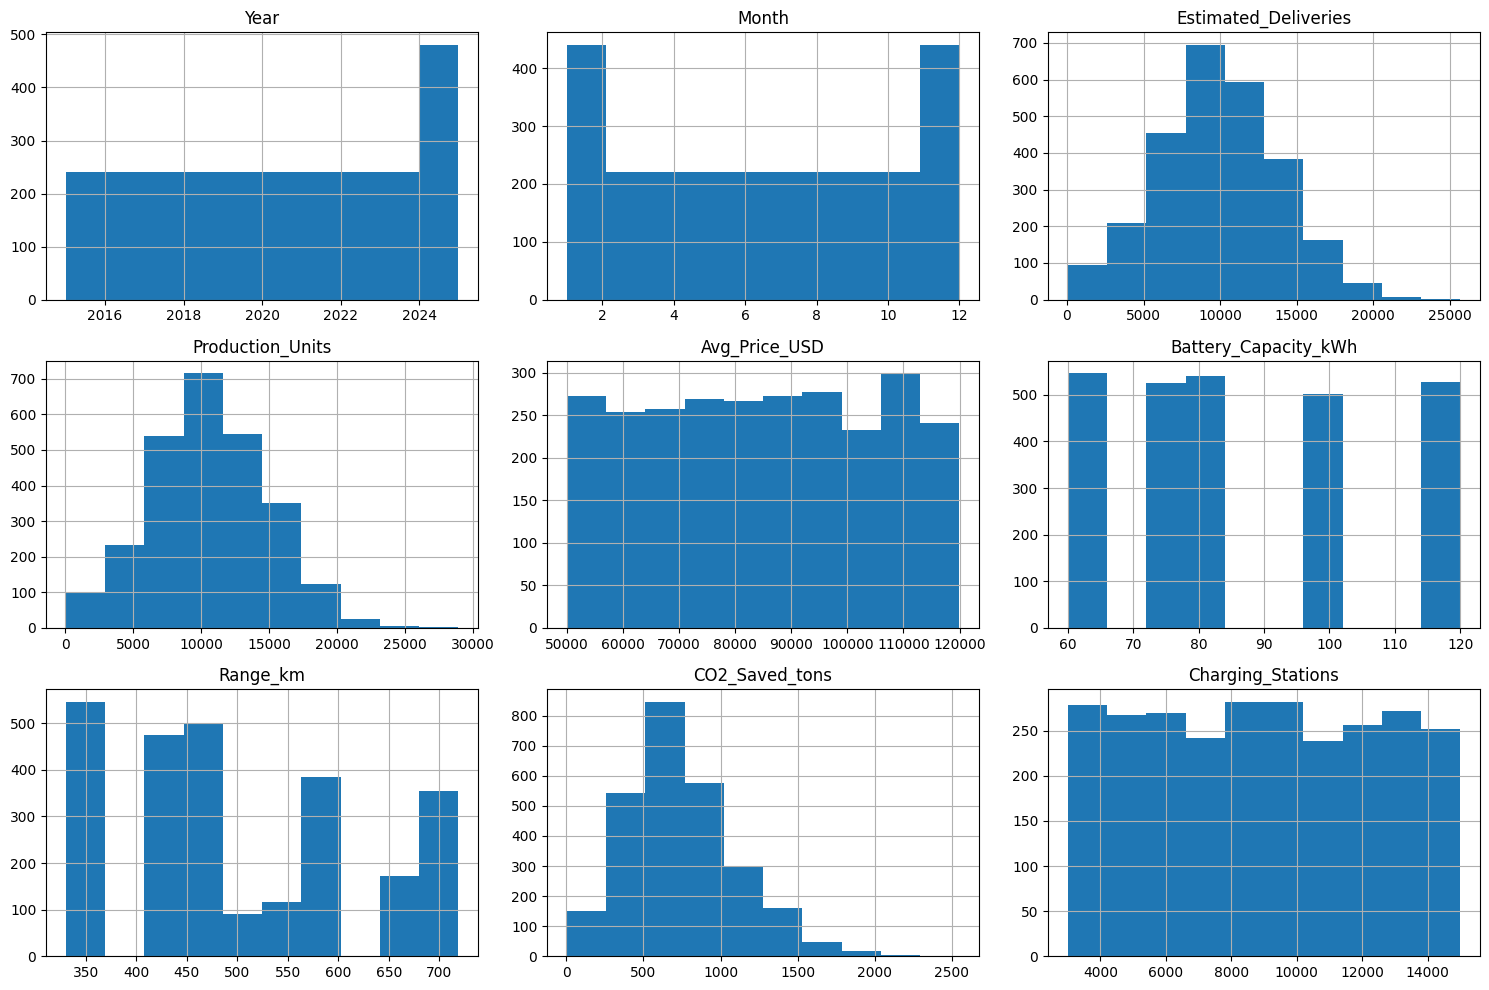

In [5]:
# Exploratory Data Analysis (EDA)

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nCorrelation Matrix:")
display(df.corr(numeric_only=True))

# Histograms for numerical columns
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()


In [6]:
# Feature Engineering & Encoding

# Convert date column if present
if 'date' in df.columns.str.lower():
    date_col = [col for col in df.columns if col.lower() == 'date'][0]
    df[date_col] = pd.to_datetime(df[date_col])

    df['Year'] = df[date_col].dt.year
    df['Month'] = df[date_col].dt.month
    df['Day'] = df[date_col].dt.day

# Encode categorical columns
encoder = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = encoder.fit_transform(df[col])

print("Feature Engineering & Encoding Completed")
display(df.head())

Feature Engineering & Encoding Completed


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [7]:
# Feature Scaling

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Feature Scaling Completed")
display(df.head())

Feature Scaling Completed


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,0.948683,-0.434524,-0.447214,0.000000,1.962744,1.705752,0.395982,1.581223,1.685972,3.169558,-0.005573,0.944062
1,-1.581139,-1.303572,-1.341641,0.707107,-1.556514,-1.523982,-1.128346,-0.578883,-0.515183,-1.400569,1.220585,-0.372490
2,-0.316228,-1.593255,1.341641,0.707107,-0.384021,-0.344347,1.639209,-0.242866,-0.167632,-0.392143,-0.005573,1.481407
3,0.316228,-1.303572,1.341641,-0.707107,-0.855661,-0.785213,0.218076,1.581223,1.752172,-0.124611,1.220585,0.115560
4,-1.264911,1.593255,0.447214,1.414214,0.623043,0.676360,1.488085,1.581223,1.330146,1.367116,-1.231731,-0.060576


In [8]:
# Train-Test Split

target = df.columns[-1]

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Target Column:", target)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Target Column: Charging_Stations
Training Shape: (2112, 11)
Testing Shape: (528, 11)


In [9]:
# Linear Regression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Results
MAE : 0.8628623608084676
MSE : 1.0028363968172997
RMSE: 1.0014171941889654
R² Score: -0.003386323343022468


In [10]:
# Ridge Regression

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge Regression")
print("MAE :", mean_absolute_error(y_test, ridge_pred))
print("MSE :", mean_squared_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R² Score:", r2_score(y_test, ridge_pred))

Ridge Regression
MAE : 0.8628348300104498
MSE : 1.0027281035764253
RMSE: 1.0013631227364155
R² Score: -0.003277970717261214


In [11]:
# Lasso Regression

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso Regression")
print("MAE :", mean_absolute_error(y_test, lasso_pred))
print("MSE :", mean_squared_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R² Score:", r2_score(y_test, lasso_pred))

Lasso Regression
MAE : 0.8632030314406578
MSE : 1.0005703488078914
RMSE: 1.0002851337533172
R² Score: -0.001119032698311928


In [12]:
# Hyperparameter Tuning (Ridge)

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Best Alpha:", grid.best_params_['alpha'])
print("Best CV Score:", grid.best_score_)
print("Test R² Score:", r2_score(y_test, best_pred))

Best Alpha: 100
Best CV Score: -0.014599360229775904
Test R² Score: -0.0024765882702979525


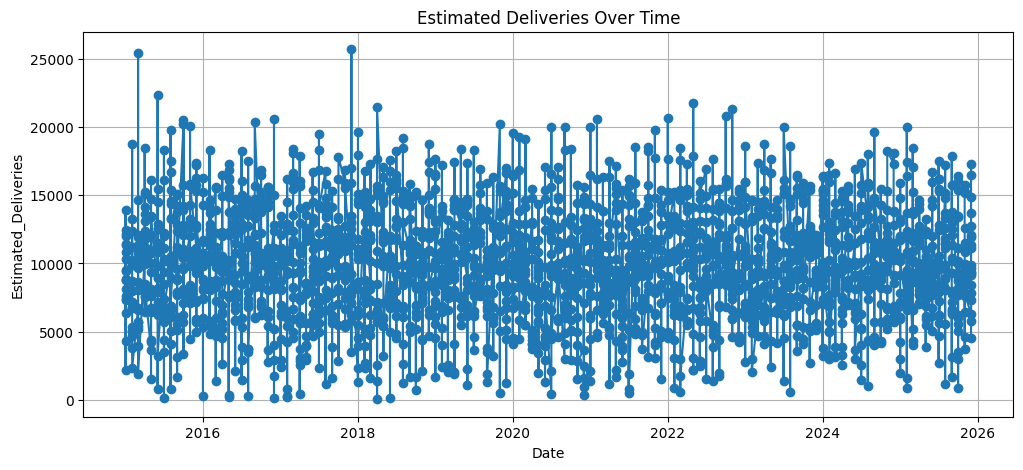

Chronological Split Example
Train Shape: (2112, 13)
Test Shape : (528, 13)


In [15]:
# Time Series Forecasting

temp = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

# Create a Date column from Year and Month
temp["Date"] = pd.to_datetime(
    temp["Year"].astype(str) + "-" + temp["Month"].astype(str) + "-01"
)

temp = temp.sort_values("Date")

# Use Estimated_Deliveries as the target
target = "Estimated_Deliveries"

plt.figure(figsize=(12,5))
plt.plot(temp["Date"], temp[target], marker='o')
plt.title("Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel(target)
plt.grid(True)
plt.show()

print("Chronological Split Example")

split = int(len(temp) * 0.8)

train = temp.iloc[:split]
test = temp.iloc[split:]

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

# Conclusion

- Loaded and cleaned the Tesla dataset.
- Performed Exploratory Data Analysis (EDA).
- Applied feature engineering and feature scaling.
- Trained Linear Regression, Ridge Regression, and Lasso Regression models.
- Performed hyperparameter tuning using GridSearchCV.
- Created a time series visualization and chronological train-test split.

This notebook demonstrates an end-to-end machine learning pipeline on Tesla deliveries and production data.